# GSM8k


In [ ]:

import json
from math_verify import parse, verify, LatexExtractionConfig, ExprExtractionConfig

def compile_predictions(predictions_file):
    extraction_target = (ExprExtractionConfig(), LatexExtractionConfig())
    results = []
    
    with open(predictions_file, 'r') as f:
        for line in f:
            data = json.loads(line)
            gold = parse(f"${data['answer']}$", extraction_config=extraction_target)
            
            # Get model generation output (usually first item)
            llm_output = data['model_generation'][0] if isinstance(data['model_generation'], list) else data['model_generation']
            answer = parse(llm_output, extraction_config=extraction_target)
            
            result = verify(gold, answer)
            results.append(result)
    
    accuracy = sum(results) / len(results) if results else 0
    return accuracy

from math import comb
def pass_at_k(n, c, k):
    """
    n: 总样本数
    c: 通过的样本数
    k: 评估的候选数
    """
    if n < k:
        return 1.0
    return 1.0 - comb(n - c, k) / comb(n, k)

def compile_predictions_BoN_passK(predictions_file):
    extraction_target = (ExprExtractionConfig(), LatexExtractionConfig())
    results = []
    with open(predictions_file, 'r') as f:
        for line in f:
            data = json.loads(line)
            gold = parse(f"${data['answer']}$", extraction_config=extraction_target)
            
            o_results = []
            # Use all generations to verify
            for llm_output in data['model_generation']:
                answer = parse(llm_output, extraction_config=extraction_target)
                result = verify(gold, answer)
                o_results.append(result)
            results.append(o_results)
    
    # 计算BoN - 检查每个问题是否至少有一个正确
    BoN = sum(1 for o_result in results if any(o_result)) / len(results) if results else 0
    
    #  计算Pass@K - 统计所有通过的样本
    total_samples = sum(len(o_result) for o_result in results)
    correct_samples = sum(sum(o_result) for o_result in results)
    passK = pass_at_k(total_samples, correct_samples, 1)
    
    return BoN, passK


In [44]:
import matplotlib.pyplot as plt

def draw_comparison_fig(baseline_x, baseline_y, seal_x, seal_y, x_label, y_label, title):
    plt.figure(figsize=(10, 5))
    plt.plot(baseline_x, baseline_y, marker='o', linestyle='-', color='b', label='Baseline')
    plt.plot(seal_x, seal_y, marker='o', linestyle='-', color='r', label='SEAL')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.ylim(bottom=0, top=1)
    plt.legend()
    plt.show()

## Example

baseline_accuracy:  0.7740712661106899
seal_accuracy:  0.8051554207733131


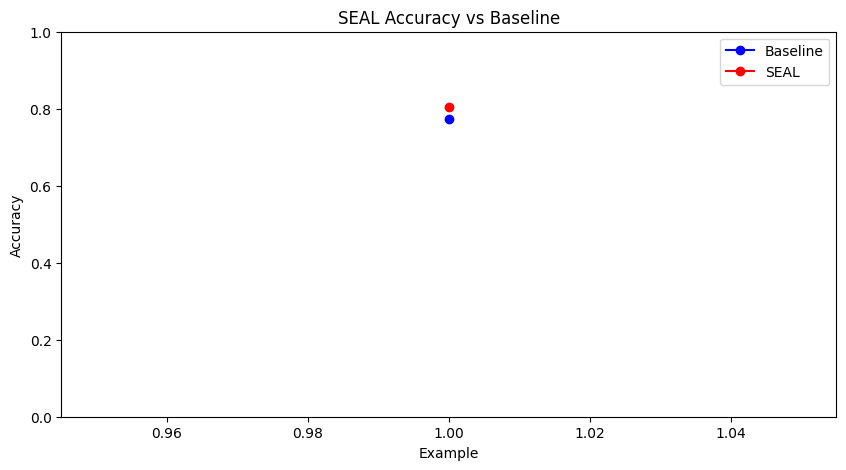

In [45]:

baseline_path = "/media/volume/llm/llm_steering_reasoning/results/deepseek-baseline/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/1/0/8192/predictions.jsonl"
seal_path = "/media/volume/llm/llm_steering_reasoning/results/deepseek-seal/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/1/0/8192/1/predictions.jsonl"

baseline_accuracies = []
seal_accuracies = []
baseline_accuracy = compile_predictions(baseline_path)
seal_accuracy = compile_predictions(seal_path)
baseline_accuracies.append(baseline_accuracy)
seal_accuracies.append(seal_accuracy)
print("baseline_accuracy: ", baseline_accuracy)
print("seal_accuracy: ", seal_accuracy)
x = [1]
y = [baseline_accuracy, seal_accuracy]
x_label = "Example"
y_label = "Accuracy"
title = "SEAL Accuracy vs Baseline"
draw_comparison_fig(x, baseline_accuracies, x, seal_accuracies, x_label, y_label, title)

## Temp

baseline_accuracy: 0.7740712661106899, seal_accuracy: 0.8051554207733131
baseline_accuracy: 0.7846853677028052, seal_accuracy: 0.8112206216830933
baseline_accuracy: 0.8119787717968158, seal_accuracy: 0.8134950720242609
baseline_accuracy: 0.8180439727065959, seal_accuracy: 0.8134950720242609
baseline_accuracy: 0.8172858225928734, seal_accuracy: 0.7952994692949203
baseline_accuracy: 0.7975739196360879, seal_accuracy: 0.7778620166793025
baseline_accuracy: 0.5170583775587566, seal_accuracy: 0.36542835481425323


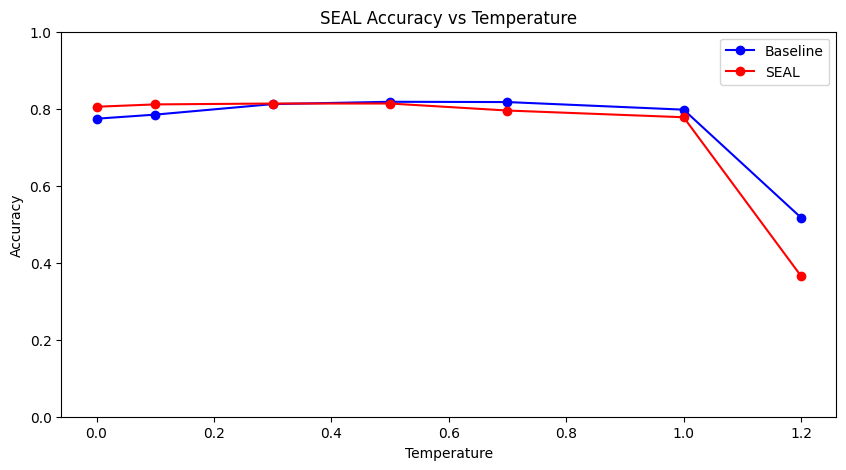

In [62]:
# temp = 0, 0.7, 1.0, 1.2
temps = [0, 0.1, 0.3, 0.5, 0.7, 1.0, 1.2]
baseline_accuracies = []
seal_accuracies = []

for temp in temps:
    baseline_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-baseline/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/1/{temp}/8192/predictions.jsonl"
    seal_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-seal/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/1/{temp}/8192/1/predictions.jsonl"

    baseline_accuracy = compile_predictions(baseline_path)
    seal_accuracy = compile_predictions(seal_path)
    baseline_accuracies.append(baseline_accuracy)
    seal_accuracies.append(seal_accuracy)
    print(f"baseline_accuracy: {baseline_accuracy}, seal_accuracy: {seal_accuracy}")

x = temps
y = seal_accuracies
x_label = "Temperature"
y_label = "Accuracy"
title = "SEAL Accuracy vs Temperature"
draw_comparison_fig(x, baseline_accuracies, x, seal_accuracies, x_label, y_label, title)

## Max Tokens

baseline_accuracy: 0.7740712661106899, seal_accuracy: 0.8051554207733131
baseline_accuracy: 0.7717968157695224, seal_accuracy: 0.8059135708870356
baseline_accuracy: 0.775587566338135, seal_accuracy: 0.8059135708870356


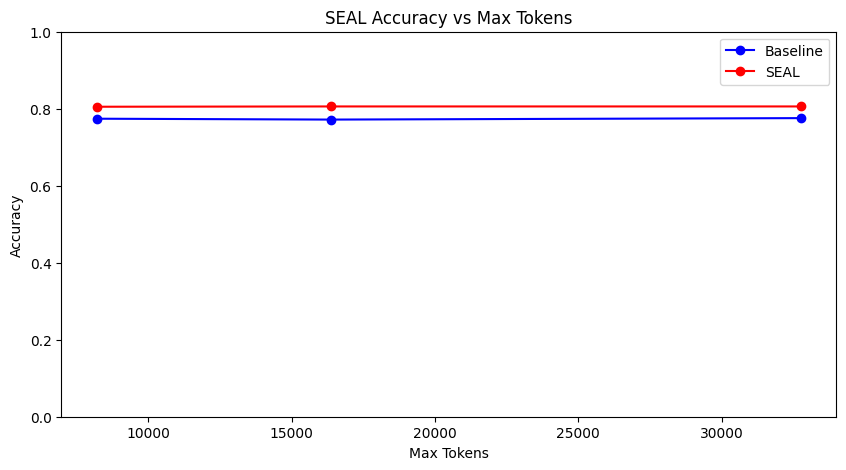

In [ ]:
max_tokens = [8192, 16384, 32768]
baseline_accuracies = []
seal_accuracies = []

for max_token in max_tokens:
    baseline_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-baseline/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/1/0/{max_token}/predictions.jsonl"
    seal_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-seal/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/1/0/{max_token}/1/predictions.jsonl"

    baseline_accuracy = compile_predictions(baseline_path)
    seal_accuracy = compile_predictions(seal_path)
    
    baseline_accuracies.append(baseline_accuracy)
    seal_accuracies.append(seal_accuracy)
    print(f"baseline_accuracy: {baseline_accuracy}, seal_accuracy: {seal_accuracy}")
    
x = max_tokens
y = seal_accuracies
x_label = "Max Tokens"
y_label = "Accuracy"
title = "SEAL Accuracy vs Max Tokens"
draw_comparison_fig(x, baseline_accuracies, x, seal_accuracies, x_label, y_label, title)

## Num of Samples  

baseline_accuracy: 0.8180439727065959, seal_accuracy: 0.7952994692949203
baseline_BoN: 0.8180439727065959, seal_BoN: 0.7952994692949203
baseline_passK: 0.8180439727065959, seal_passK: 0.7952994692949205
baseline_accuracy: 0.8066717210007581, seal_accuracy: 0.7854435178165277
baseline_BoN: 0.9476876421531463, seal_BoN: 0.9446550416982562
baseline_passK: 0.8112206216830933, seal_passK: 0.7996588324488249
baseline_accuracy: 0.8248673237300985, seal_accuracy: 0.8097043214556482
baseline_BoN: 0.9658832448824868, seal_BoN: 0.9651250947687642
baseline_passK: 0.8137319939347991, seal_passK: 0.7999431387414708


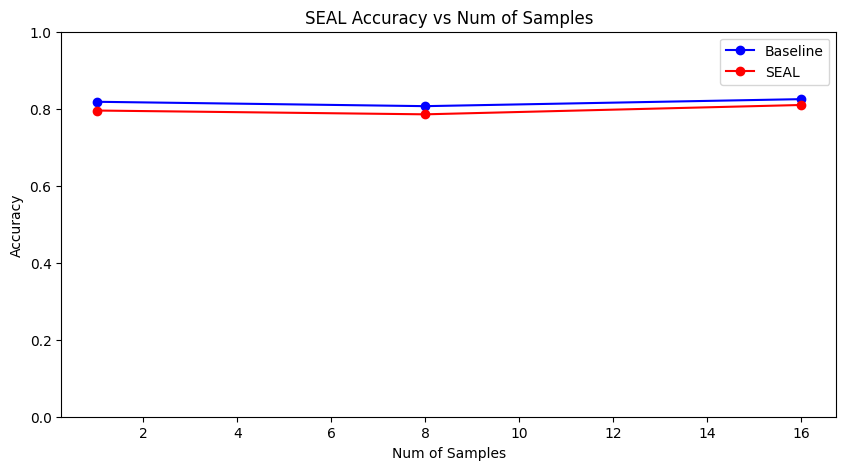

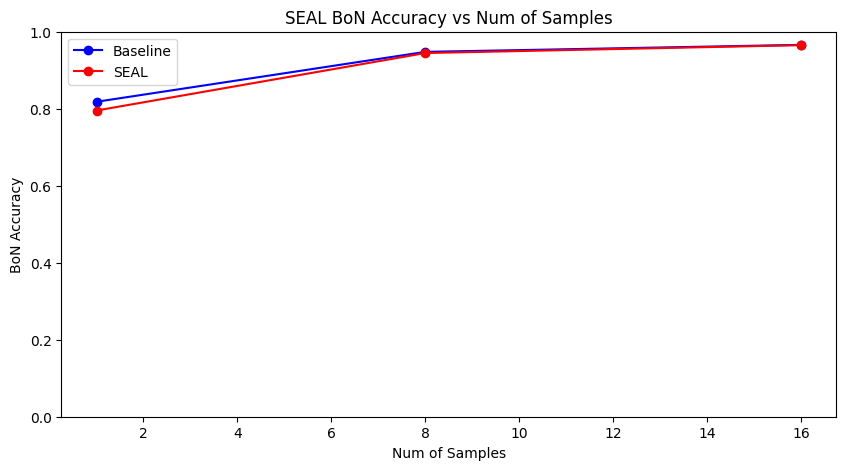

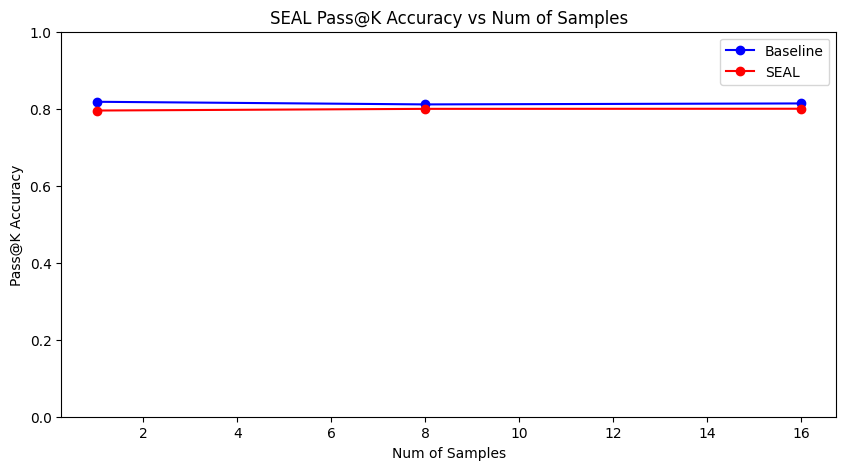

In [59]:
num_samples = [1, 8, 16]
baseline_accuracies = []
seal_accuracies = []
baseline_BoN_accuracies = []
seal_BoN_accuracies = []
baseline_passK_accuracies = []
seal_passK_accuracies = []

for num_sample in num_samples:
    baseline_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-baseline/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/{num_sample}/0.7/8192/predictions.jsonl"
    seal_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-seal/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/{num_sample}/0.7/8192/1/predictions.jsonl"

    baseline_accuracy = compile_predictions(baseline_path)
    seal_accuracy = compile_predictions(seal_path)
    baseline_BoN, baseline_passK = compile_predictions_BoN_passK(baseline_path)
    seal_BoN, seal_passK = compile_predictions_BoN_passK(seal_path)
    
    baseline_accuracies.append(baseline_accuracy)
    seal_accuracies.append(seal_accuracy)
    baseline_BoN_accuracies.append(baseline_BoN)
    seal_BoN_accuracies.append(seal_BoN)
    baseline_passK_accuracies.append(baseline_passK)
    seal_passK_accuracies.append(seal_passK)
    print(f"baseline_accuracy: {baseline_accuracy}, seal_accuracy: {seal_accuracy}")
    print(f"baseline_BoN: {baseline_BoN}, seal_BoN: {seal_BoN}")
    print(f"baseline_passK: {baseline_passK}, seal_passK: {seal_passK}")

x = num_samples
y = seal_accuracies
x_label = "Num of Samples"
y_label = "Accuracy"
title = "SEAL Accuracy vs Num of Samples"
draw_comparison_fig(x, baseline_accuracies, x, seal_accuracies, x_label, y_label, title)
x = num_samples
y = seal_BoN_accuracies
x_label = "Num of Samples"
y_label = "BoN Accuracy"
title = "SEAL BoN Accuracy vs Num of Samples"
draw_comparison_fig(x, baseline_BoN_accuracies, x, seal_BoN_accuracies, x_label, y_label, title)
x = num_samples
y = seal_passK_accuracies
x_label = "Num of Samples"
y_label = "Pass@K Accuracy"
title = "SEAL Pass@K Accuracy vs Num of Samples"
draw_comparison_fig(x, baseline_passK_accuracies, x, seal_passK_accuracies, x_label, y_label, title)



## Scale

baseline_accuracy: 0.7740712661106899
seal_accuracy: 0.8142532221379833
seal_accuracy: 0.8051554207733131
seal_accuracy: 0.8051554207733131


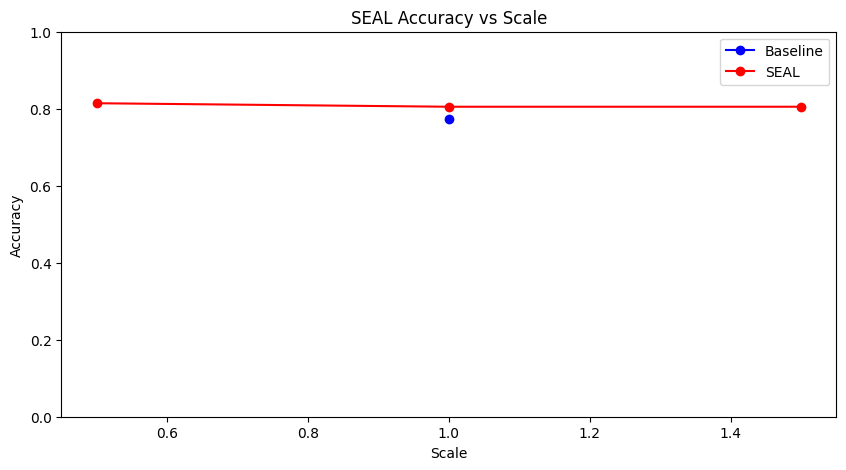

In [53]:
scale = [0.5, 1, 1.5]
baseline_accuracies = []
seal_accuracies = []
baseline_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-baseline/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/1/0/8192/predictions.jsonl"
baseline_accuracy = compile_predictions(baseline_path)
baseline_accuracies.append(baseline_accuracy)
print(f"baseline_accuracy: {baseline_accuracy}")

for s in scale:
    seal_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-seal/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/1/0/8192/{s}/predictions.jsonl"
    seal_accuracy = compile_predictions(seal_path)
    seal_accuracies.append(seal_accuracy)
    print(f"seal_accuracy: {seal_accuracy}")
x = scale
y = seal_accuracies
x_label = "Scale"
y_label = "Accuracy"
title = "SEAL Accuracy vs Scale"
draw_comparison_fig([1], baseline_accuracies, x, seal_accuracies, x_label, y_label, title)

# MATH500

In [66]:
import json
from math_verify import parse, verify, LatexExtractionConfig, ExprExtractionConfig

def compile_predictions(predictions_file):
    extraction_target = (ExprExtractionConfig(), LatexExtractionConfig())
    results = []
    
    with open(predictions_file, 'r') as f:
        for line in f:
            data = json.loads(line)
            gold = parse(f"${data['answer']}$", extraction_config=extraction_target)
            
            # Get model generation output (usually first item)
            llm_output = data['model_generation'][0] if isinstance(data['model_generation'], list) else data['model_generation']
            answer = parse(llm_output, extraction_config=extraction_target)
            
            result = verify(gold, answer)
            results.append(result)
    
    accuracy = sum(results) / len(results) if results else 0
    return accuracy

from math import comb
def pass_at_k(n, c, k):
    """
    n: 总样本数
    c: 通过的样本数
    k: 评估的候选数
    """
    if n < k:
        return 1.0
    return 1.0 - comb(n - c, k) / comb(n, k)

def compile_predictions_BoN_passK(predictions_file):
    extraction_target = (ExprExtractionConfig(), LatexExtractionConfig())
    results = []
    with open(predictions_file, 'r') as f:
        for line in f:
            data = json.loads(line)
            gold = parse(f"${data['answer']}$", extraction_config=extraction_target)
            
            o_results = []
            # Use all generations to verify
            for llm_output in data['model_generation']:
                answer = parse(llm_output, extraction_config=extraction_target)
                result = verify(gold, answer)
                o_results.append(result)
            results.append(o_results)
    
    # 计算BoN - 检查每个问题是否至少有一个正确
    BoN = sum(1 for o_result in results if any(o_result)) / len(results) if results else 0
    
    #  计算Pass@K - 统计所有通过的样本
    total_samples = sum(len(o_result) for o_result in results)
    correct_samples = sum(sum(o_result) for o_result in results)
    passK = pass_at_k(total_samples, correct_samples, 1)
    
    return BoN, passK


In [68]:
import matplotlib.pyplot as plt

def draw_comparison_fig(baseline_x, baseline_y, seal_x, seal_y, x_label, y_label, title):
    plt.figure(figsize=(10, 5))
    plt.plot(baseline_x, baseline_y, marker='o', linestyle='-', color='b', label='Baseline')
    plt.plot(seal_x, seal_y, marker='o', linestyle='-', color='r', label='SEAL')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.ylim(bottom=0, top=1)
    plt.legend()
    plt.show()

## Example

baseline_accuracy:  0.718
seal_accuracy:  0.794


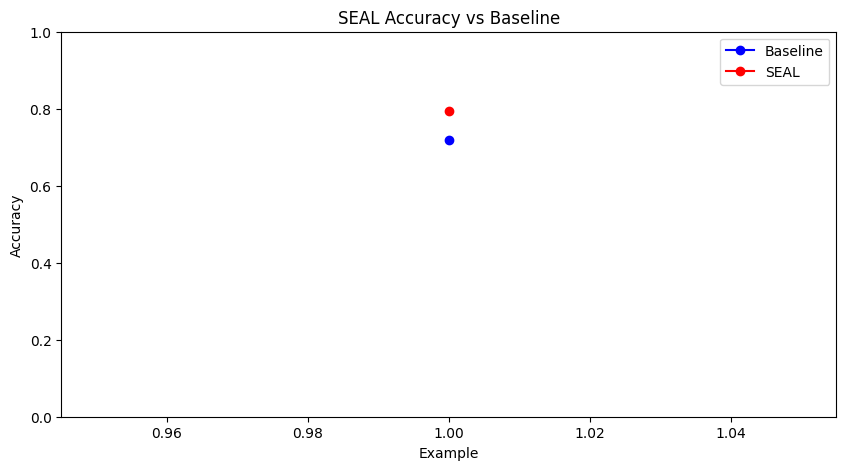

In [69]:

baseline_path = "/media/volume/llm/llm_steering_reasoning/results/deepseek-baseline/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/MATH500/1/0/8192/predictions.jsonl"
seal_path = "/media/volume/llm/llm_steering_reasoning/results/deepseek-seal/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/MATH500/1/0/8192/1/predictions.jsonl"

baseline_accuracies = []
seal_accuracies = []
baseline_accuracy = compile_predictions(baseline_path)
seal_accuracy = compile_predictions(seal_path)
baseline_accuracies.append(baseline_accuracy)
seal_accuracies.append(seal_accuracy)
print("baseline_accuracy: ", baseline_accuracy)
print("seal_accuracy: ", seal_accuracy)
x = [1]
y = [baseline_accuracy, seal_accuracy]
x_label = "Example"
y_label = "Accuracy"
title = "SEAL Accuracy vs Baseline"
draw_comparison_fig(x, baseline_accuracies, x, seal_accuracies, x_label, y_label, title)

## Temp

baseline_accuracy: 0.718, seal_accuracy: 0.794
baseline_accuracy: 0.722, seal_accuracy: 0.81
baseline_accuracy: 0.786, seal_accuracy: 0.792
baseline_accuracy: 0.804, seal_accuracy: 0.822
baseline_accuracy: 0.816, seal_accuracy: 0.8
baseline_accuracy: 0.788, seal_accuracy: 0.798
baseline_accuracy: 0.496, seal_accuracy: 0.408


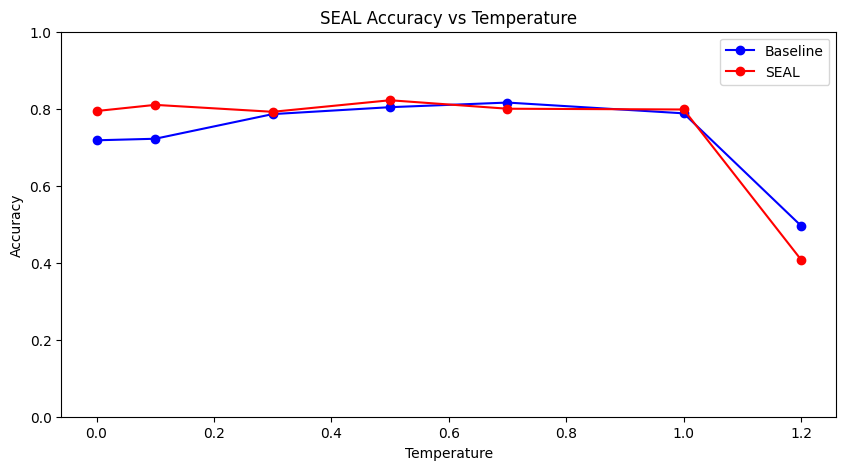

In [74]:
# temp = 0, 0.7, 1.0, 1.2
temps = [0, 0.1, 0.3, 0.5, 0.7, 1.0, 1.2]
baseline_accuracies = []
seal_accuracies = []

for temp in temps:
    baseline_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-baseline/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/MATH500/1/{temp}/8192/predictions.jsonl"
    seal_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-seal/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/MATH500/1/{temp}/8192/1/predictions.jsonl"

    baseline_accuracy = compile_predictions(baseline_path)
    seal_accuracy = compile_predictions(seal_path)
    baseline_accuracies.append(baseline_accuracy)
    seal_accuracies.append(seal_accuracy)
    print(f"baseline_accuracy: {baseline_accuracy}, seal_accuracy: {seal_accuracy}")

x = temps
y = seal_accuracies
x_label = "Temperature"
y_label = "Accuracy"
title = "SEAL Accuracy vs Temperature"
draw_comparison_fig(x, baseline_accuracies, x, seal_accuracies, x_label, y_label, title)

## Max Tokens

baseline_accuracy: 0.718, seal_accuracy: 0.794
baseline_accuracy: 0.734, seal_accuracy: 0.796
baseline_accuracy: 0.736, seal_accuracy: 0.8


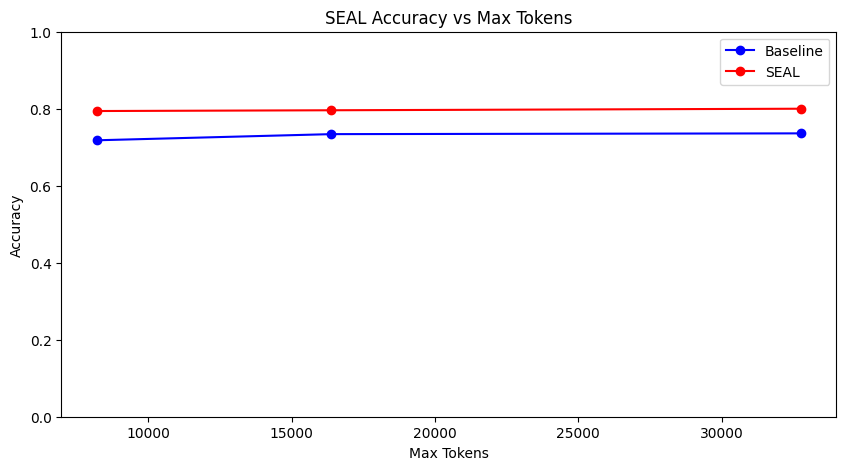

In [71]:
max_tokens = [8192, 16384, 32768]
baseline_accuracies = []
seal_accuracies = []

for max_token in max_tokens:
    baseline_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-baseline/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/MATH500/1/0/{max_token}/predictions.jsonl"
    seal_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-seal/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/MATH500/1/0/{max_token}/1/predictions.jsonl"

    baseline_accuracy = compile_predictions(baseline_path)
    seal_accuracy = compile_predictions(seal_path)
    
    baseline_accuracies.append(baseline_accuracy)
    seal_accuracies.append(seal_accuracy)
    print(f"baseline_accuracy: {baseline_accuracy}, seal_accuracy: {seal_accuracy}")
    
x = max_tokens
y = seal_accuracies
x_label = "Max Tokens"
y_label = "Accuracy"
title = "SEAL Accuracy vs Max Tokens"
draw_comparison_fig(x, baseline_accuracies, x, seal_accuracies, x_label, y_label, title)

## Num of Samples  

baseline_accuracy: 0.816, seal_accuracy: 0.8
baseline_BoN: 0.816, seal_BoN: 0.8
baseline_passK: 0.8160000000000001, seal_passK: 0.8
baseline_accuracy: 0.816, seal_accuracy: 0.822
baseline_BoN: 0.946, seal_BoN: 0.948
baseline_passK: 0.8089999999999999, seal_passK: 0.8125
baseline_accuracy: 0.794, seal_accuracy: 0.812
baseline_BoN: 0.95, seal_BoN: 0.968
baseline_passK: 0.8049999999999999, seal_passK: 0.81575


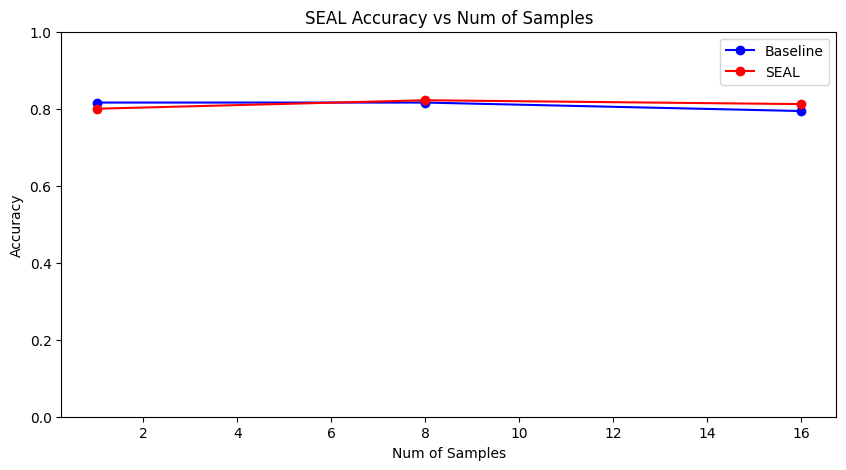

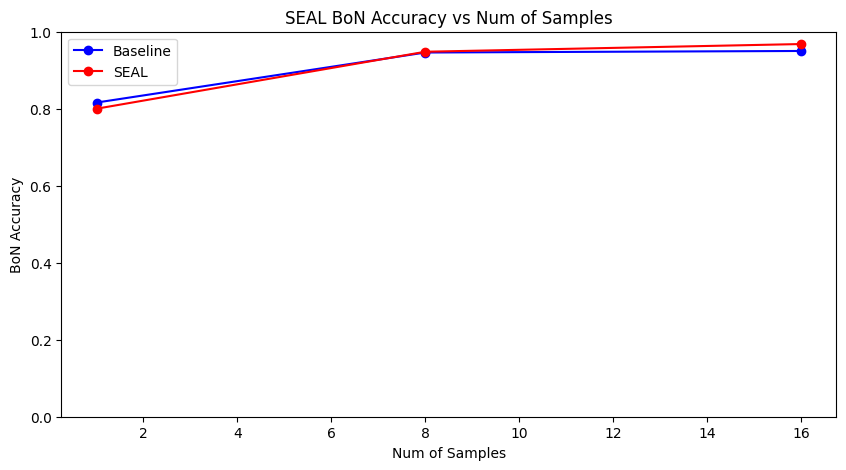

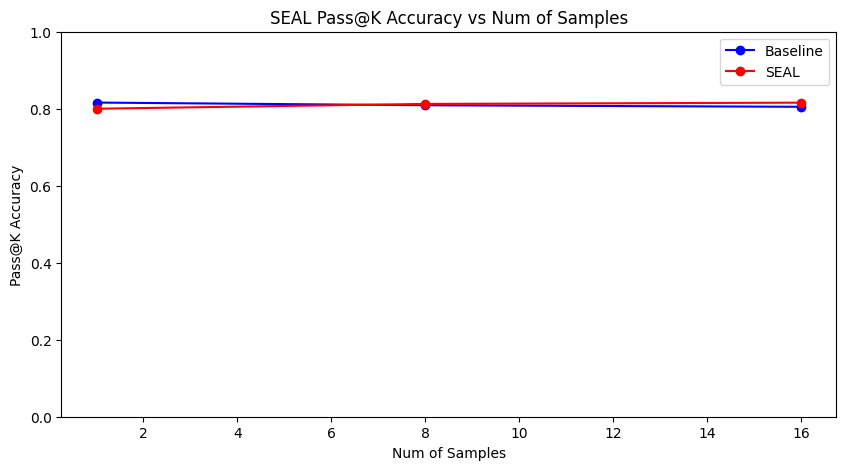

In [72]:
num_samples = [1, 8, 16]
baseline_accuracies = []
seal_accuracies = []
baseline_BoN_accuracies = []
seal_BoN_accuracies = []
baseline_passK_accuracies = []
seal_passK_accuracies = []

for num_sample in num_samples:
    baseline_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-baseline/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/MATH500/{num_sample}/0.7/8192/predictions.jsonl"
    seal_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-seal/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/MATH500/{num_sample}/0.7/8192/1/predictions.jsonl"

    baseline_accuracy = compile_predictions(baseline_path)
    seal_accuracy = compile_predictions(seal_path)
    baseline_BoN, baseline_passK = compile_predictions_BoN_passK(baseline_path)
    seal_BoN, seal_passK = compile_predictions_BoN_passK(seal_path)
    
    baseline_accuracies.append(baseline_accuracy)
    seal_accuracies.append(seal_accuracy)
    baseline_BoN_accuracies.append(baseline_BoN)
    seal_BoN_accuracies.append(seal_BoN)
    baseline_passK_accuracies.append(baseline_passK)
    seal_passK_accuracies.append(seal_passK)
    print(f"baseline_accuracy: {baseline_accuracy}, seal_accuracy: {seal_accuracy}")
    print(f"baseline_BoN: {baseline_BoN}, seal_BoN: {seal_BoN}")
    print(f"baseline_passK: {baseline_passK}, seal_passK: {seal_passK}")

x = num_samples
y = seal_accuracies
x_label = "Num of Samples"
y_label = "Accuracy"
title = "SEAL Accuracy vs Num of Samples"
draw_comparison_fig(x, baseline_accuracies, x, seal_accuracies, x_label, y_label, title)
x = num_samples
y = seal_BoN_accuracies
x_label = "Num of Samples"
y_label = "BoN Accuracy"
title = "SEAL BoN Accuracy vs Num of Samples"
draw_comparison_fig(x, baseline_BoN_accuracies, x, seal_BoN_accuracies, x_label, y_label, title)
x = num_samples
y = seal_passK_accuracies
x_label = "Num of Samples"
y_label = "Pass@K Accuracy"
title = "SEAL Pass@K Accuracy vs Num of Samples"
draw_comparison_fig(x, baseline_passK_accuracies, x, seal_passK_accuracies, x_label, y_label, title)



## Scale

baseline_accuracy: 0.718
seal_accuracy: 0.762
seal_accuracy: 0.794
seal_accuracy: 0.742


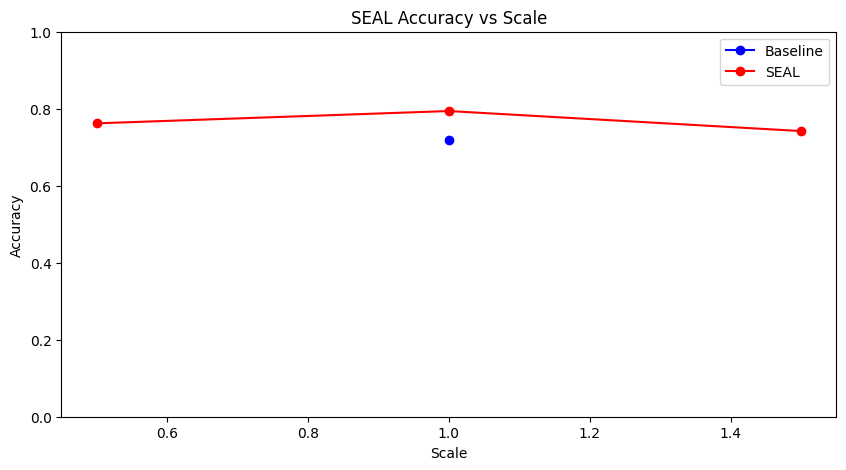

In [73]:
scale = [0.5, 1, 1.5]
baseline_accuracies = []
seal_accuracies = []
baseline_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-baseline/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/MATH500/1/0/8192/predictions.jsonl"
baseline_accuracy = compile_predictions(baseline_path)
baseline_accuracies.append(baseline_accuracy)
print(f"baseline_accuracy: {baseline_accuracy}")

for s in scale:
    seal_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-seal/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/MATH500/1/0/8192/{s}/predictions.jsonl"
    seal_accuracy = compile_predictions(seal_path)
    seal_accuracies.append(seal_accuracy)
    print(f"seal_accuracy: {seal_accuracy}")
x = scale
y = seal_accuracies
x_label = "Scale"
y_label = "Accuracy"
title = "SEAL Accuracy vs Scale"
draw_comparison_fig([1], baseline_accuracies, x, seal_accuracies, x_label, y_label, title)